## Check frequency functions

In [165]:
import numpy as np
import os
import matplotlib.pyplot as plt
import sys

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from utils import quickread, add_PCA_coords

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()

/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src


In [127]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

In [216]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..','..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37143140325363977
Computed theta: 0.32738211937605843


100%|██████████| 14502/14502 [00:08<00:00, 1720.80it/s]

3265.70225762244


In [217]:
f = compute_empirical_freqs(Z, W, q=21)
print(f.shape)
f_flat = f.flatten()
print(f_flat.shape)

(21, 63)
(1323,)


## Load generated sequences / test sequences to compare

In [215]:
# load sequences from /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/jdoms_J_py/gen_3000_3000_1.npy
#sequences = np.load('/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/jdoms_J_py/gen_3000_3000_1.npy')
sequences = np.load('/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/generated_vect_sequences_brute_force_condJPCA_comp/gen_vect_plm_randinit_n_iter1500_nb_seq5000_Nbins35PCA_comp.npy')
print(sequences.shape)
# remove last two columns (PCA components)
sequences = sequences[:,:-2]
f_gen = compute_empirical_freqs(sequences.T, None, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

(5000, 65)
(21, 63)


In [ ]:
# load from test sequences
Z_test,W_test = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_test2.fasta')
print(Z_test.shape)
f_test = compute_empirical_freqs(Z_test, W_test, q=21)
f_test_flat = f_test.flatten()
print(f_test.shape)

Total sequences read: 3739
Sequences after filtering: 3739
Sampling 100000 pairs out of 6988191 total pairs.
Mean fraction of identical positions (sampled): 0.37064
Computed theta: 0.32808115691776385


100%|██████████| 3739/3739 [00:00<00:00, 6018.58it/s]

1325.4984819766414


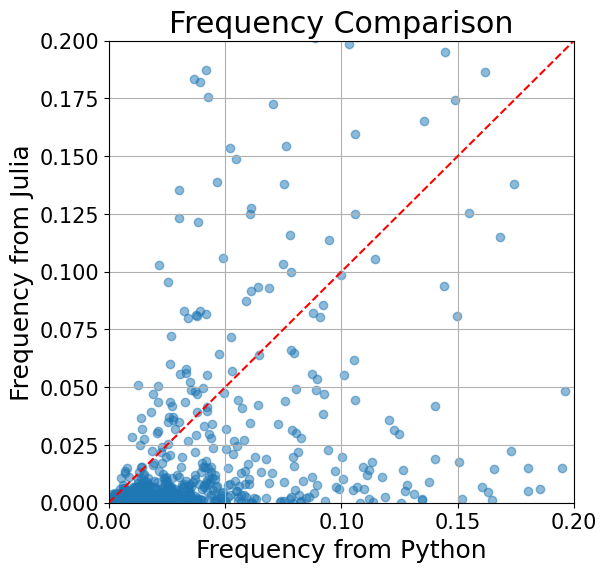

In [218]:
# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

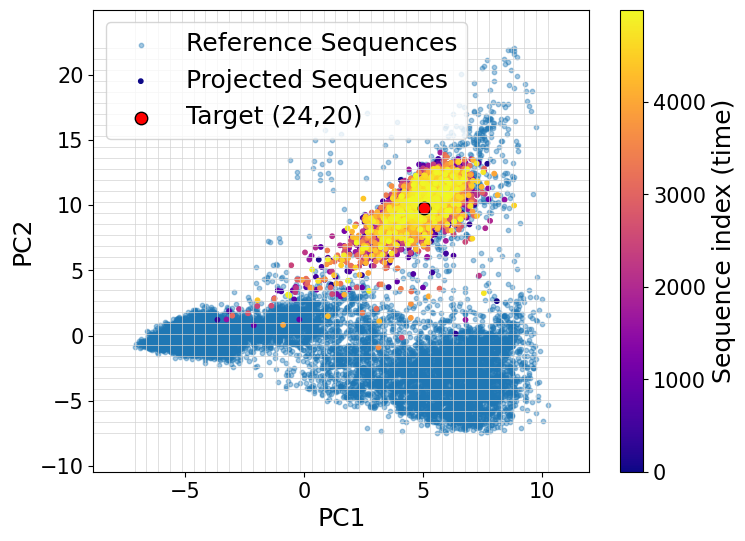

In [224]:

plot_projected_pca_time(Z.T,sequences, target_coords=np.array([24,20]), Nbins=35)

In [209]:
def extract_sequences_around_PCA(seq,target,N,dist,W=None):
    print(seq.shape)
    seq_PCA=add_PCA_coords(seq,N)
    print(seq_PCA.shape)
    PCA_list=seq_PCA[:,-2:]
    list_dist=np.sqrt(np.sum((PCA_list-target)**2,axis=1))
    print(list_dist.shape)
    index_list=list_dist<dist
    filtered_seqs=seq[index_list,:]
    print(filtered_seqs.shape)
    if W is None:
        print(seq.shape)
        print(index_list.sum())
        print(np.shape(np.array(index_list)))
        print(np.array(index_list[:10]))
        return filtered_seqs
    else:
        return seq[index_list,:], W[index_list]

In [222]:
seq = Z.T
seq = np.array(seq)
train_seqs_target = extract_sequences_around_PCA(seq, np.array([24,20]), 35, 5)
f_target_flat = compute_empirical_freqs(train_seqs_target.T, None, q=21)

(14502, 63)
(14502, 65)
(14502,)
(812, 63)
(14502, 63)
812
(14502,)
[False False  True False False False False False False False]


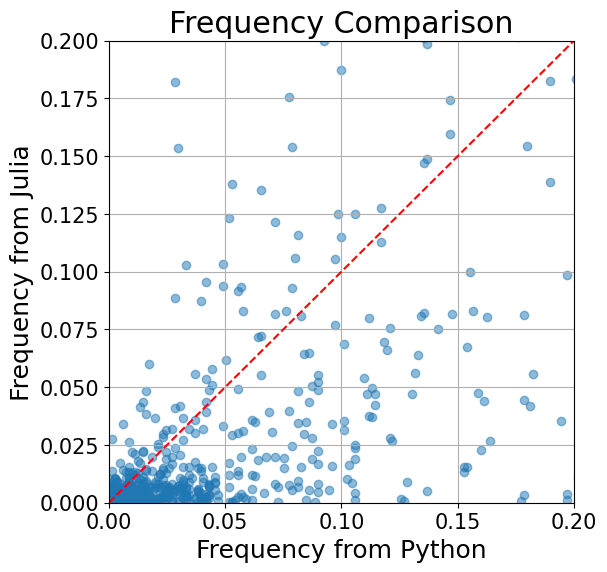

In [223]:
# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_target_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

# AUTO-REG

In [138]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)

from plm_gen_methods import generate_plm_n_save, generate_coords_n_save, generate_plm_vect_n_save
from seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, find_target_seq, sequences_from_fasta
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
sys.path.pop(0) 
import torch


In [75]:
# load J_tens from Q,K,V in results
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.insert(0, parent_dir)
from model import arAttentionModel
from dcascore import attention_heads_from_model

print(parent_dir)
sys.path.pop(0)  # Removes the parent_dir from sys.path
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_AR/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_AR/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_AR/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]
model=arAttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
print(f"Q shape: {Q_1.shape}, K shape: {K_1.shape}, V shape: {V_1.shape}")
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)
i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices > j_indices).float().unsqueeze(0)  # shape (1, L, L)
W = W * mask
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)


/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src
Current directory: /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST
Q shape: torch.Size([64, 10, 63]), K shape: torch.Size([64, 10, 63]), V shape: torch.Size([64, 21, 21])
torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [76]:
from tqdm import tqdm
import numpy as np
import os
from seq_utils import letter_to_num
from tqdm import tqdm
from scipy.special import softmax
class SequenceAR:
    def __init__(self,J,N_seq,beta=1):
        self.J=J
        self.N_seq=N_seq
        self.L=J.shape[-1]
        self.beta=beta
        self.q=J.shape[0]
        self.seq_array=np.zeros((N_seq,self.L))

    def energy_position_k(self,k, aa):
        n_seq = self.seq_array.shape[0]
        # indices of positions < k
        idx = np.arange(k)

        # shape (n_seq, k)
        seq_sub = self.seq_array[:, idx]
        #print(seq_sub.shape)

        # gather J[k, j, aa, seq_sub] for all j<k, seqs
        # this broadcasts: (k,) vs (n_seq, k)
        e = self.J[aa, seq_sub,k, idx[None, :]]
        #print(e.shape)

        # sum over positions <k, leaving (n_seq,)
        return e.sum(axis=1)
    
    def ene_J_autre(self,J_autre,k, aa):

        idx = np.arange(k)

        # shape (n_seq, k)
        seq_sub = self.seq_array[:, idx]
        

        # gather J[k, j, aa, seq_sub] for all j<k, seqs
        # this broadcasts: (k,) vs (n_seq, k)
        e2 = J_autre[aa, seq_sub,k, idx[None, :]]
        e2=e2.sum(axis=1)
        

        # sum over positions <k, leaving (n_seq,)
        return  e2


    def prob_per_position(self,site):
        all_proba=np.zeros((self.N_seq,self.q))
        for aa in range(self.q):
            all_proba[:,aa]=self.beta*self.energy_position_k(site,aa)
        all_proba=softmax(all_proba,axis=1)
        return all_proba
    def compare_J(self,J_autre,site):
        all_p_old=self.prob_per_position(site)
        all_proba=np.zeros((self.N_seq,self.q))
        for aa in range(self.q):
            all_proba[:,aa]=self.beta*self.ene_J_autre(J_autre,site,aa)
        all_proba=softmax(all_proba,axis=1)
        diff_proba=abs(all_p_old-all_proba).mean().item()
        return diff_proba
    
    def gen_seq(self):
        for site in tqdm(range(self.L)):
            all_proba_site=self.prob_per_position(site)
            u = np.random.rand(self.N_seq, 1)  # (N_seq, 1) uniform samples
            cum_probs = np.cumsum(all_proba_site, axis=1)  # (N_seq, q)
            choices = (u < cum_probs).argmax(axis=1)
            self.seq_array[:, site] = choices

    def save_sequence(self, save_dir, filename):
        """Save sequence array as a compressed .npz file."""
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, filename + ".npz")
        np.savez_compressed(path, seq_array=self.seq_array)

    def load_sequence(self, save_dir, filename):
        """Load sequence array from a compressed .npz file."""
        path = os.path.join(save_dir, filename + ".npz")
        data = np.load(path)
        self.seq_array = data["seq_array"]
        return self.seq_array

In [77]:
save_dir = "AR_gen"
nb_seq=20000
save_name = f"ar_{nb_seq}"

seq=SequenceAR(Jtens,nb_seq,1)
seq.gen_seq()
seq.save_sequence(save_dir,save_name)
gen_seq=seq.load_sequence(save_dir,save_name)

  0%|          | 0/63 [00:00<?, ?it/s]

/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_75266/3599251060.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  all_proba[:,aa]=self.beta*self.energy_position_k(site,aa)
100%|██████████| 63/63 [00:09<00:00,  6.52it/s]


In [78]:
# load Z,W from ar generated sequences
cwd = os.getcwd()
Z_gen = np.load(cwd + f'/AR_gen/{save_name}.npz')
Z_gen = np.array(Z_gen['seq_array'],dtype=int)
print(Z_gen.shape)
f_ar = compute_empirical_freqs(Z_gen.T, None, q=21)
f_ar_flat = f_ar.flatten()
print(f_ar_flat.shape)

(20000, 63)
(1323,)


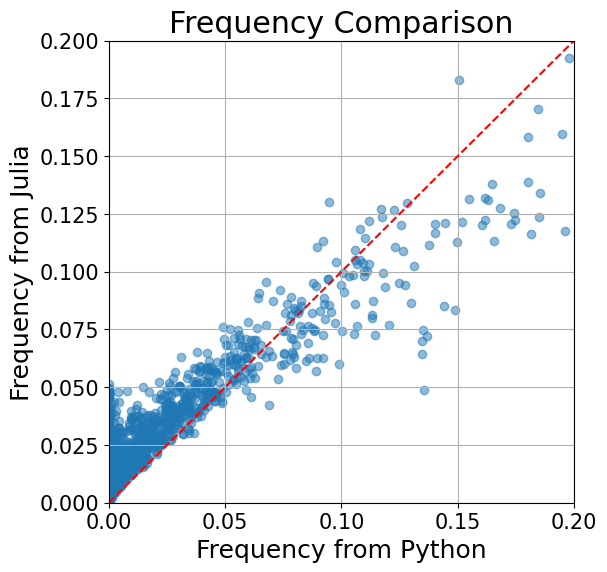

In [79]:
# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_flat, f_ar_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

train_seqs: 63
generated_seqs: 20000


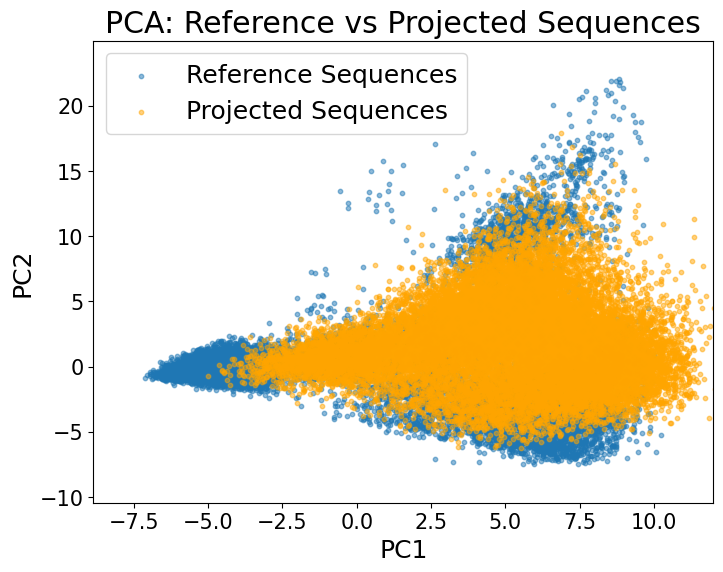

In [74]:
print("train_seqs:", len(Z))
print("generated_seqs:", len(Z_gen))
plot_projected_pca(Z.T,Z_gen)

In [67]:
# load Q, K, V from JDOMS, arQ...
import h5py
import numpy as np

def load_jld2(filename, key):
    with h5py.File(filename, "r") as f:
        data = f[key][()]  # NumPy array
    # Permute axes so indexing matches Julia
    return np.transpose(data, axes=range(data.ndim)[::-1])

# Example usage
Q = load_jld2("JDOMS/arQ_tensor.jld2", "arQ")
K = load_jld2("JDOMS/arK_tensor.jld2", "arK")
V = load_jld2("JDOMS/arV_tensor.jld2", "arV")


In [94]:
arJ_julia = load_jld2("JDOMS/arJ_tensor.jld2", "arJ")
print(arJ_julia.shape)
# permute to (q,q,L,L)
arJ_julia = np.transpose(arJ_julia, (2,3,0,1))
print(arJ_julia.shape)
arJ_julia = torch.tensor(arJ_julia)

(63, 63, 21, 21)
(21, 21, 63, 63)


In [95]:
save_dir = "AR_gen"
nb_seq=20000
save_name = f"jl_ar_{nb_seq}"

seq=SequenceAR(arJ_julia,nb_seq,1)
seq.gen_seq()
seq.save_sequence(save_dir,save_name)
gen_seq=seq.load_sequence(save_dir,save_name)

  0%|          | 0/63 [00:00<?, ?it/s]/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_75266/3599251060.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  all_proba[:,aa]=self.beta*self.energy_position_k(site,aa)
100%|██████████| 63/63 [00:09<00:00,  6.85it/s]


In [96]:
# load Z,W from ar generated sequences
cwd = os.getcwd()
print("loaded from AR_gen:  ", cwd + f'/AR_gen/{save_name}.npz')
Z_gen = np.load(cwd + f'/AR_gen/{save_name}.npz')
Z_gen = np.array(Z_gen['seq_array'],dtype=int)
print(Z_gen.shape)
f_ar = compute_empirical_freqs(Z_gen.T, None, q=21)
f_ar_flat = f_ar.flatten()
print(f_ar_flat.shape)

loaded from AR_gen:   /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/AR_gen/jl_ar_20000.npz
(20000, 63)
(1323,)


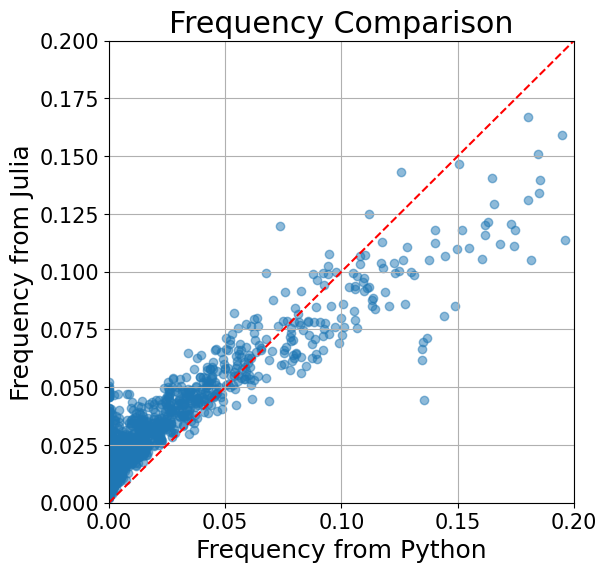

In [97]:
# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_flat, f_ar_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()

train_seqs: 63
generated_seqs: 20000


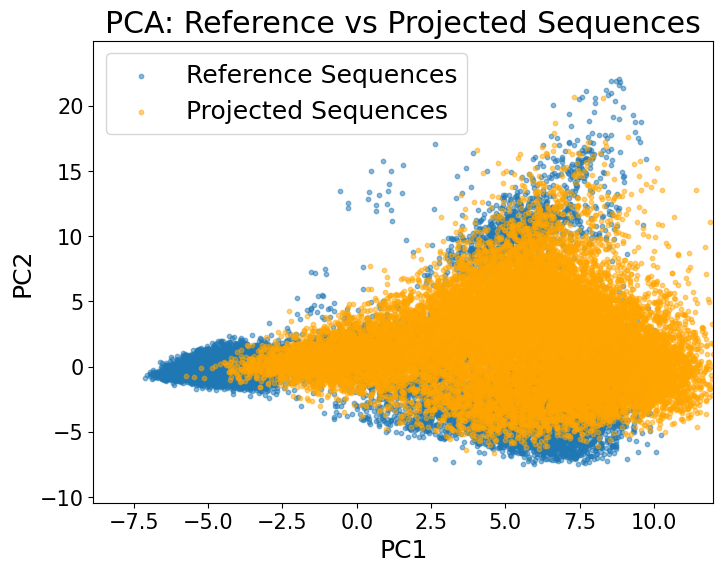

In [98]:
print("train_seqs:", len(Z))
print("generated_seqs:", len(Z_gen))
plot_projected_pca(Z.T,Z_gen)

# PF AR gen

In [118]:
def clean_fasta(infile, outfile):
    with open(infile, "r") as fin, open(outfile, "w") as fout:
        header = None
        seq_parts = []
        for line in fin:
            line = line.strip()
            if line.startswith(">"):
                # write previous sequence if exists
                if header is not None:
                    fout.write(header + "\n")
                    fout.write("".join(seq_parts) + "\n")
                header = line
                seq_parts = []
            else:
                # keep only uppercase A–Z and dashes
                clean_line = "".join(ch for ch in line if ("A" <= ch <= "Z") or ch == "-")
                seq_parts.append(clean_line)
        # write last entry
        if header is not None:
            fout.write(header + "\n")
            fout.write("".join(seq_parts) + "\n")

# Example usage:
clean_fasta("PF/PF00014.fasta", "PF/PF00014_cleaned.fasta")


In [119]:
Z,W = quickread("PF/PF00014_cleaned.fasta")
f_ar = compute_empirical_freqs(Z, W, q=21)

Total sequences read: 4915
Sequences after filtering: 4915
Sampling 100000 pairs out of 6539536 total pairs.
Mean fraction of identical positions (sampled): 0.3394358490566038
Computed theta: 0.3582414772569357


100%|██████████| 3617/3617 [00:00<00:00, 6047.14it/s]


1435.5651179248391


In [100]:
# load Q, K, V from JDOMS, arQ...
import h5py
import numpy as np

def load_jld2(filename, key):
    with h5py.File(filename, "r") as f:
        data = f[key][()]  # NumPy array
    # Permute axes so indexing matches Julia
    return np.transpose(data, axes=range(data.ndim)[::-1])

# Example usage
Q = load_jld2("PF/PFarQ_tensor.jld2", "PFarQ")
K = load_jld2("PF/PFarK_tensor.jld2", "PFarK")
V = load_jld2("PF/PFarV_tensor.jld2", "PFarV")

PFarJ_julia = load_jld2("PF/PFarJ_tensor.jld2", "PFarJ")
print(PFarJ_julia.shape)
# permute to (q,q,L,L)
PFarJ_julia = np.transpose(PFarJ_julia, (2,3,0,1))
print(PFarJ_julia.shape)
PFarJ_julia = torch.tensor(PFarJ_julia)

save_dir = "AR_PFgen"
nb_seq=20000
save_name = f"jl_ar_{nb_seq}"

seq=SequenceAR(PFarJ_julia,nb_seq,1)
seq.gen_seq()
seq.save_sequence(save_dir,save_name)
gen_seq=seq.load_sequence(save_dir,save_name)

(53, 53, 21, 21)
(21, 21, 53, 53)


  0%|          | 0/53 [00:00<?, ?it/s]

/var/folders/dv/fpf7xq8j6yzfxjs7g9c_bbyc0000gn/T/ipykernel_75266/3599251060.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  all_proba[:,aa]=self.beta*self.energy_position_k(site,aa)
100%|██████████| 53/53 [00:06<00:00,  7.59it/s]


loaded from AR_PFgen:   /Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src/PLM/TEST/AR_PFgen/jl_ar_20000.npz
(20000, 53)
(1113,)
(1113,)
(1113,)
(1060,)


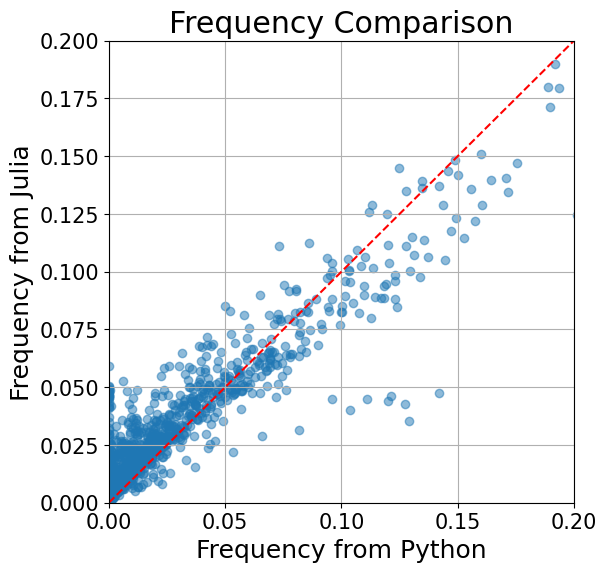

In [121]:
# load Z,W from ar generated sequences
cwd = os.getcwd()
print("loaded from AR_PFgen:  ", cwd + f'/AR_PFgen/{save_name}.npz')
Z_gen = np.load(cwd + f'/AR_PFgen/{save_name}.npz')
Z_gen = np.array(Z_gen['seq_array'],dtype=int)
print(Z_gen.shape)
fs_ar = compute_empirical_freqs(Z_gen.T, None, q=21)
fs_ar_flat = fs_ar.flatten()
print(fs_ar_flat.shape)

#f_ar = load_jld2("PF/PFarF1_tensor.jld2", "PFarF1")
# turn to numpy and flatten
#f_ar = np.array(f_ar)
f_ar_flat = f_ar.flatten()

print(f_ar_flat.shape)
print(fs_ar_flat.shape)
print(fs_ar_flat[:-53].shape)

# freq-freq plot
plt.figure(figsize=(6,6))
plt.scatter(f_ar_flat, fs_ar_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')
plt.plot([0, 0.2], [0, 0.2], 'r--')  # y=x line
plt.xlim(0, 0.2)
plt.ylim(0, 0.2)
plt.grid()
plt.show()